<a href="https://colab.research.google.com/github/remyaP12/WebProject/blob/main/lstm_flood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Based from the tutorial of Jason Brownlee on Recurrent Neural Networks
%matplotlib inline

from __future__ import print_function

import os
os.environ["THEANO_FLAGS"] = "mode=FAST_RUN,device=gpu,floatX=float32"


import numpy as np
import matplotlib.pyplot as plt
import pandas
import math


from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler

plt.style.use('ggplot')


In [7]:
# fix random seed for reproducibility
np.random.seed(10)

In [8]:
#Use the flood_data.csv dataset
dataframe = pandas.read_csv('/content/flood_train.csv', usecols=[1], engine='python', skipfooter=3)
dataset   = dataframe.values
dataset   = dataset.astype('float32')
dataframe.head()

,waterlevel
0,0.27
1,0.26
2,0.27
3,0.28
4,0.28


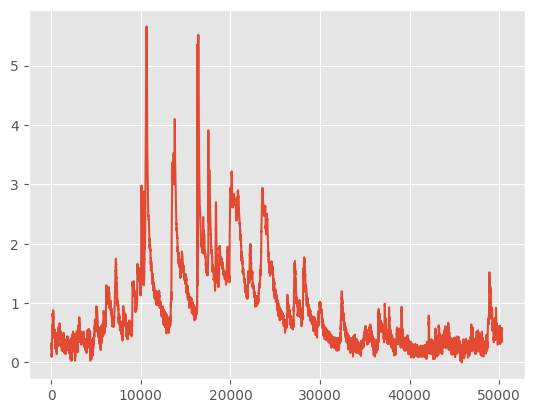

In [9]:
plt.plot(dataset)

In [10]:
# normalize the dataset
scaler  = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [11]:
# split into train and test sets
train_size  = int(len(dataset) * 0.67)
test_size   = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
print(len(train), len(test))

33710 16604


----------------- TRAINING DATA -----------------


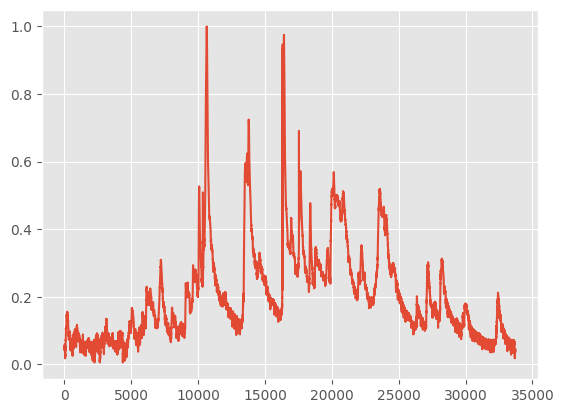

----------------- TEST DATA -----------------


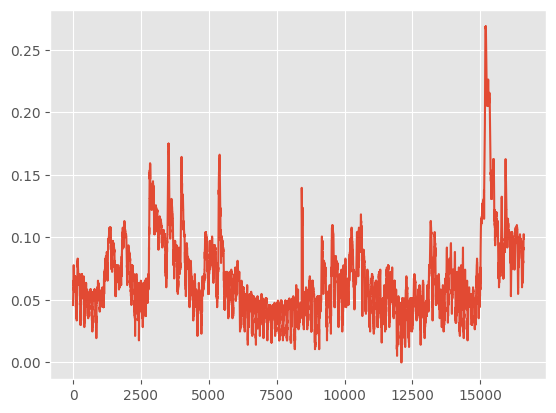

In [12]:
print('----------------- TRAINING DATA -----------------')
plt.plot(train)
plt.show()
print('----------------- TEST DATA -----------------')
plt.plot(test)
plt.show()

In [13]:
# This function creates a sliding window of the dataset.
def create_dataset(dataset, sliding_window=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-sliding_window-1):
        a = dataset[i:(i+sliding_window), 0]
        dataX.append(a)
        dataY.append(dataset[i + sliding_window, 0])
    return np.array(dataX), np.array(dataY)

In [14]:
# use a n-10 sliding window equivalent to 2.5 hours of historical data
slide_window   = 10
trainX, trainY = create_dataset(train, slide_window)
testX, testY   = create_dataset(test, slide_window)

In [15]:
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX  = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [16]:

model = Sequential()
model.add(LSTM(4, input_shape=(1, slide_window)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=50, batch_size=1, verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
33699/33699 - 114s - 3ms/step - loss: 1.6409e-04
Epoch 2/50
33699/33699 - 112s - 3ms/step - loss: 1.2132e-04
Epoch 3/50
33699/33699 - 111s - 3ms/step - loss: 1.1247e-04
Epoch 4/50
33699/33699 - 110s - 3ms/step - loss: 1.0975e-04
Epoch 5/50
33699/33699 - 113s - 3ms/step - loss: 1.0787e-04
Epoch 6/50
33699/33699 - 111s - 3ms/step - loss: 1.0854e-04
Epoch 7/50
33699/33699 - 111s - 3ms/step - loss: 1.0529e-04
Epoch 8/50
33699/33699 - 112s - 3ms/step - loss: 1.0660e-04
Epoch 9/50
33699/33699 - 111s - 3ms/step - loss: 1.0483e-04
Epoch 10/50
33699/33699 - 113s - 3ms/step - loss: 1.0456e-04
Epoch 11/50
33699/33699 - 111s - 3ms/step - loss: 1.0252e-04
Epoch 12/50
33699/33699 - 110s - 3ms/step - loss: 1.0154e-04
Epoch 13/50
33699/33699 - 142s - 4ms/step - loss: 1.0361e-04
Epoch 14/50
33699/33699 - 111s - 3ms/step - loss: 1.0186e-04
Epoch 15/50
33699/33699 - 142s - 4ms/step - loss: 1.0167e-04
Epoch 16/50
33699/33699 - 111s - 3ms/step - loss: 1.0020e-04
Epoch 17/50
33699/33699 - 111s - 

In [21]:
# Print out the evaluation for both the
trainScore = model.evaluate(trainX, trainY, verbose=0)
trainScore = math.sqrt(trainScore)
trainScore = scaler.inverse_transform(np.array([[trainScore]]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = model.evaluate(testX, testY, verbose=0)
testScore = math.sqrt(testScore)
testScore = scaler.inverse_transform(np.array([[testScore]]))
print('Test Score: %.2f RMSE' % (testScore))

/tmp/ipykernel_2059/3392814234.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Train Score: %.2f RMSE' % (trainScore))


Train Score: 0.05 RMSE
Test Score: 0.02 RMSE


/tmp/ipykernel_2059/3392814234.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Test Score: %.2f RMSE' % (testScore))


1054/1054 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


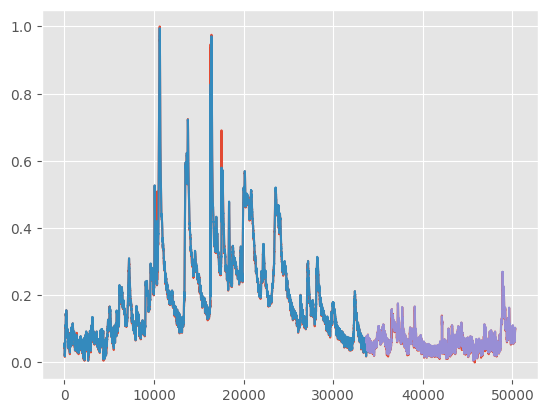

In [22]:
trainPredict = model.predict(trainX)
testPredict  = model.predict(testX)

# shift train predictions for plotting
trainPredictPlot       = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[slide_window:len(trainPredict)+slide_window, :] = trainPredict

# shift test predictions for plotting
testPredictPlot       = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(slide_window*2)+1:len(dataset)-1, :] = testPredict

# plot baseline and predictions
plt.plot(dataset)
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

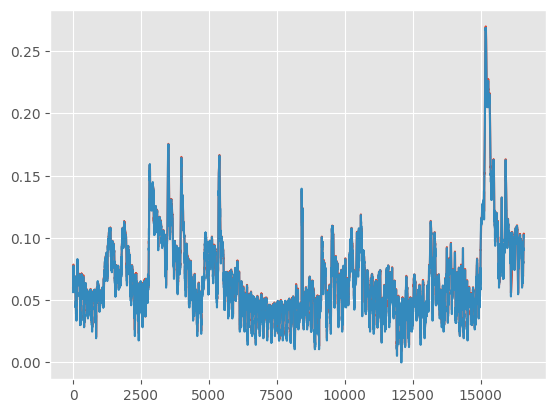

In [23]:
plt.plot(testPredict)
plt.plot(testY)

In [25]:
# Test the network on an unseen data
unseen = pandas.read_csv('flood_test.csv',sep=',')

In [26]:
unseen.head()

,datetime,rainfall,waterlevel
0,1/1/2013 0:10,0.0,0.21
1,1/1/2013 0:21,0.0,0.21
2,1/1/2013 0:30,0.0,0.40
3,1/1/2013 1:30,0.0,0.49
4,1/1/2013 1:40,0.0,0.59


In [27]:
unseen_test = unseen['waterlevel'].values

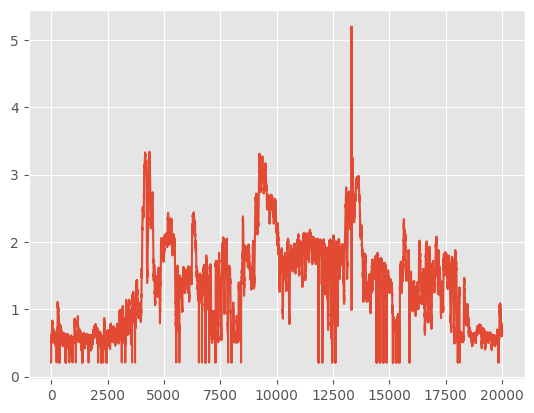

In [28]:
plt.plot(unseen_test[0:20000])

In [29]:
unseen_clean = []
for i in unseen_test:
    unseen_clean.append([i])
unseen_clean = np.asarray(unseen_clean).astype('float32')
unseen_clean = scaler.fit_transform(unseen_clean)

In [30]:
features,labels = create_dataset(unseen_clean, slide_window)
features        = np.reshape(features, (109186,1, 10))

In [31]:
unseen_results = model.predict(features)

3413/3413 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


-------------------- Predicted --------------------


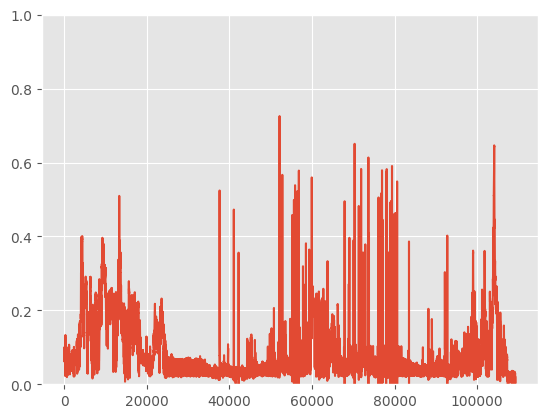

-------------------- Ground Truth --------------------


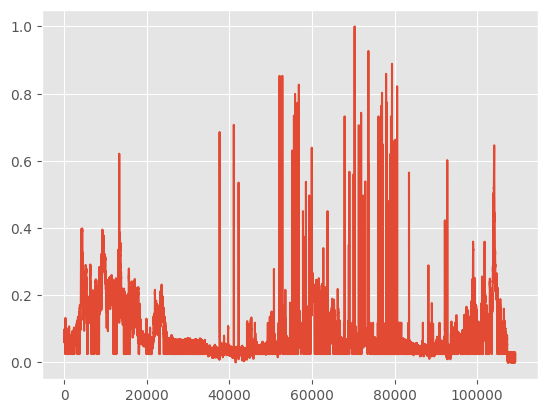

In [32]:
plt.gca().set_ylim(bottom=0)
plt.gca().set_ylim(top=1)

print('-------------------- Predicted --------------------')
plt.plot(unseen_results)
plt.show()


print('-------------------- Ground Truth --------------------')
plt.plot(labels)
plt.show()

In [33]:
# Check the root mean squared error for the new test set

testScore = model.evaluate(features, labels, verbose=0)
testScore = math.sqrt(testScore)
testScore = scaler.inverse_transform(np.array([[testScore]]))
print('Test Score: %.2f RMSE' % (testScore))

Test Score: 0.16 RMSE


/tmp/ipykernel_2059/341839013.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Test Score: %.2f RMSE' % (testScore))


#### It seems that the network is having a hard time predicting higher flood level values
#### Checking the first 20000 data shows that the network is relatively comfortable on predicting ahead of time flood level values when the flood level  aren't extreme

----------------- Predicted ---------------


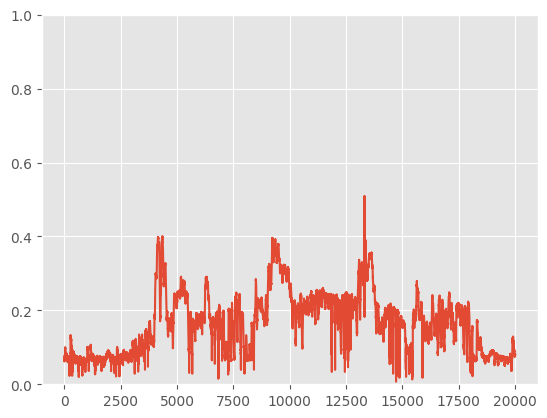

----------------- Ground Truth ---------------


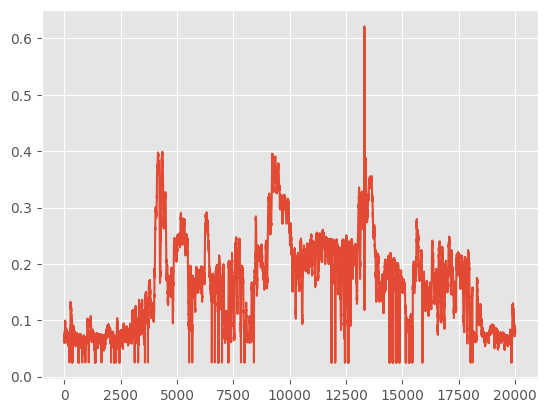

In [34]:
plt.gca().set_ylim(bottom=0)
plt.gca().set_ylim(top=1)

print('----------------- Predicted ---------------')
plt.plot(unseen_results[0:20000])
plt.show()

print('----------------- Ground Truth ---------------')
plt.plot(labels[0:20000])
plt.show()